In [1]:
using Clapeyron, Metaheuristics, Printf

In [2]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
water,18.02,1.2047,2.801457,353.94,1,1
methylamine,31.06,2.3967,2.8906,214.94,1,1
"""

unlike_parameter = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
water,methylamine,-0.01
"""

assoc_parameter = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
methylamine,H,methylamine,e,684.3,0.095103
water,H,water,e,2425.67,0.045
methylamine,H,water,e,1554.985,0.065410896
methylamine,e,water,H,1168.35,0
"""

model = PCSAFT(["water", "methylamine"], userlocations = [like_parameter, unlike_parameter, assoc_parameter])

println(model.params.epsilon.values)
println(model.params.sigma.values)
println("======================")
println("kij = ", (1  - ((model.params.epsilon.values[2])/(sqrt(model.params.epsilon.values[1] * model.params.epsilon.values[4])))))

[353.94 278.5767191607368; 278.5767191607368 214.94]
[2.8014570000000003e-10 2.8460285e-10; 2.8460285e-10 2.8906000000000003e-10]
kij = -0.010000000000000009


In [3]:
function vle_p(model::EoSModel, x_water::Float64)
    P = 101325 #ganti sesuai available data
    bub = bubble_temperature(model, P, [x_water , 1-x_water])
    T = bub[1]
    y = bub[4][1]
    return T
end

function vle_y(model::EoSModel, x_water::Float64)
    P = 101325 #ganti sesuai available data
    bub = bubble_temperature(model, P, [x_water , 1-x_water])
    p = bub[1]
    y = bub[4][1]
    return y
end

vle_y (generic function with 1 method)

In [8]:
toestimate = [
    Dict(
        :param   => :epsilon,
        :indices => (1,2),
        :lower   => 200.,
        :upper   => 500.0,
        :guess   => 179.
    )
]

1-element Vector{Dict{Symbol, Any}}:
 Dict(:upper => 500.0, :param => :epsilon, :indices => (1, 2), :guess => 179.0, :lower => 200.0)

In [9]:
# Run this ONCE to fix your CSV files
function fix_line_endings(filename)
    content = read(filename, String)
    fixed = replace(content, "\r\n" => "\n")
    write(filename, fixed)
    println("Fixed: $filename")
end

fix_line_endings("vlep_methylamine.csv")
fix_line_endings("vley_methylamine.csv")

estimator, objective, x0, upper, lower = Estimation(
    model,
    toestimate,
    [
        "vlep_methylamine.csv"
        "vley_methylamine.csv"
    ]
)
 
println("Initial objective value: ", objective(x0))

Fixed: vlep_methylamine.csv
Fixed: vley_methylamine.csv
Initial objective value: 1.0e100


In [10]:
method = ECA(; options = Options(iterations = 1000000, seed = 42))
 
params_opt, model_opt = optimize(objective, estimator, method)

([348.8716790273653], PCSAFT{BasicIdeal, Float64}("water", "methylamine"))

In [11]:
println(model_opt.params.epsilon.values)
println(model_opt.params.sigma.values)
println("kij = ", (1  - ((model_opt.params.epsilon.values[2])/(sqrt(model_opt.params.epsilon.values[1] * model_opt.params.epsilon.values[4])))))

[353.94 348.8716790273653; 348.8716790273653 214.94]
[2.8014570000000003e-10 2.8460285e-10; 2.8460285e-10 2.8906000000000003e-10]
kij = -0.264859450133482


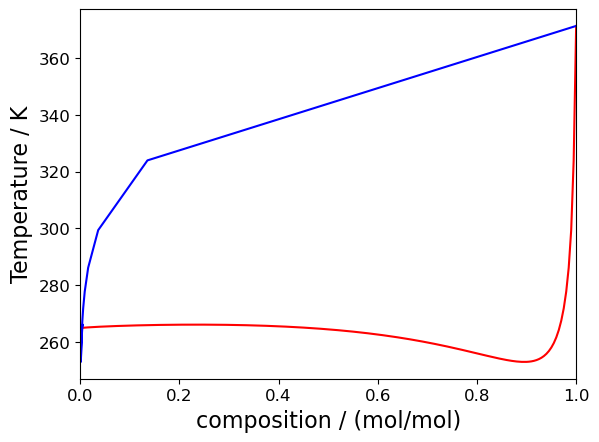

([240.0, 260.0, 280.0, 300.0, 320.0, 340.0, 360.0, 380.0], PyCall.PyObject[PyObject Text(0, 240.0, '240'), PyObject Text(0, 260.0, '260'), PyObject Text(0, 280.0, '280'), PyObject Text(0, 300.0, '300'), PyObject Text(0, 320.0, '320'), PyObject Text(0, 340.0, '340'), PyObject Text(0, 360.0, '360'), PyObject Text(0, 380.0, '380')])

In [17]:
import PyPlot; const plt = PyPlot
using Clapeyron

N    = 201
p    = 93300

x    = LinRange(0., 1.,  N)
T    = zeros(N)
y    = zeros(N)

v0 = nothing
for i in 1:N
    if i==1
        bub = bubble_temperature(model, p, [x[i], 1-x[i]])
        T[i] = bub[1]
        y[i] = bub[4][1]
        v0   = vcat(bub[1],log10.([bub[2],bub[3]]),[x[i+1],1-x[i+1]])
    else
        bub = bubble_temperature(model, p, [x[i], 1-x[i]]; v0 = v0)
        T[i] = bub[1]
        y[i] = bub[4][1]
        v0   = vcat(bub[1],log10.([bub[2],bub[3]]),bub[4])
    end
end

plt.clf()
plt.plot(x, T, color="red")
plt.plot(y, T, color="blue")
plt.xlabel("composition / (mol/mol)",fontsize=16)
plt.ylabel("Temperature / K",fontsize=16)
plt.xlim([0,1])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
     

In [14]:
using CSV, DataFrames, Printf

function calculate_AAD(model, csv_file, property_func)
    df = CSV.read(csv_file, DataFrame, comment="#", skipto=4)
    
    input_col  = names(df)[1]          # first column = input (T)
    output_col = names(df)[2]          # second column = out_xxx (experimental)
    
    inputs   = df[!, input_col]
    exp_vals = df[!, output_col]
    
    println("\n=== AAD: $csv_file ===")
    @printf("%-10s  %-12s  %-12s  %-8s\n", input_col, "exp", "calc", "ARD%")
    
    errors = Float64[]
    for (i, x) in enumerate(inputs)
        calc = property_func(model, x)
        err  = abs(calc - exp_vals[i]) / abs(exp_vals[i]) * 100
        push!(errors, err)
        @printf("%-10.4f  %-12.6f  %-12.6f  %-8.4f\n", x, exp_vals[i], calc, err)
    end
    
    aard = sum(errors) / length(errors)
    @printf("AARD = %.4f%%\n", aard)
    return aard
end

calculate_AAD (generic function with 1 method)

In [15]:
aard_p   = calculate_AAD(model_opt, "vlep_methylamine.csv", vle_p)

┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593



=== AAD: vlep_methylamine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.5055      288.670000    283.065777    1.9414  
0.5636      294.020000    288.779803    1.7823  
0.6138      299.710000    295.128808    1.5285  
0.6522      304.890000    301.091005    1.2460  
0.6906      310.820000    308.210906    0.8394  
0.7179      315.960000    314.079545    0.5952  
0.7433      320.630000    320.193760    0.1361  
0.7654      325.590000    326.031996    0.1358  
0.7830      329.860000    331.002125    0.3462  
0.7999      334.210000    335.995596    0.5343  
0.8175      339.460000    341.346730    0.5558  
0.8331      343.330000    346.122965    0.8135  
0.8479      347.510000    350.580100    0.8835  
0.8601      351.510000    354.122420    0.7432  
0.8704      353.850000    356.970249    0.8818  
0.8800      356.420000    359.472337    0.8564  
0.9039      362.240000    364.894791    0.7329  
0.9120      364.350000    366.432254    0.5715  
0.9191      365.350000   

0.6584566655017295

In [16]:
aard_p   = calculate_AAD(model_opt, "vley_methylamine.csv", vle_y)

┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593



=== AAD: vley_methylamine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.5055      0.005200      0.002622      49.5715 
0.5636      0.008700      0.004719      45.7572 
0.6138      0.014300      0.008448      40.9220 
0.6522      0.021500      0.013884      35.4227 
0.6906      0.033100      0.023915      27.7480 
0.7179      0.046900      0.036219      22.7732 
0.7433      0.063200      0.054342      14.0152 
0.7654      0.085500      0.078314      8.4045  
0.7830      0.109700      0.105319      3.9938  
0.7999      0.140000      0.140117      0.0832  
0.8175      0.181100      0.187989      3.8040  
0.8331      0.227400      0.242130      6.4774  
0.8479      0.281100      0.304556      8.3444  
0.8601      0.334000      0.364018      8.9873  
0.8704      0.384000      0.419275      9.1862  
0.8800      0.434600      0.474169      9.1048  
0.9039      0.573300      0.618285      7.8466  
0.9120      0.622200      0.666993      7.1991  
0.9191      0.664800     

12.309389423921063